In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sentiment-prediction-on-movie-reviews/movies.csv
/kaggle/input/sentiment-prediction-on-movie-reviews/sample.csv
/kaggle/input/sentiment-prediction-on-movie-reviews/train.csv
/kaggle/input/sentiment-prediction-on-movie-reviews/test.csv


**IMPORTING NECESSARY LIBRARIES**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import BernoulliNB,MultinomialNB
from sklearn import tree
from sklearn.model_selection import RandomizedSearchCV

**LOADING THE DATA**

In [5]:
movie=pd.read_csv('/kaggle/input/sentiment-prediction-on-movie-reviews/movies.csv')
train=pd.read_csv('/kaggle/input/sentiment-prediction-on-movie-reviews/train.csv')
test=pd.read_csv('/kaggle/input/sentiment-prediction-on-movie-reviews/test.csv')


# EXPLORATORY DATA ANALYSIS


In [6]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162758 entries, 0 to 162757
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   movieid             162758 non-null  object
 1   reviewerName        162758 non-null  object
 2   isFrequentReviewer  162758 non-null  bool  
 3   reviewText          156311 non-null  object
 4   sentiment           162758 non-null  object
dtypes: bool(1), object(4)
memory usage: 5.1+ MB


In [7]:
train.describe()

,movieid,reviewerName,isFrequentReviewer,reviewText,sentiment
count,162758,162758,162758,156311,162758
unique,16812,4482,2,155071,2
top,escape_the_terminator_tyler_durden_astonish,Sherri Morrison,False,Parental Content Review,POSITIVE
freq,708,962,113189,29,108761


There are many reviews for the same movie with differing sentiments

No of unique Reviewers is very small compared to the total reviews

In [8]:
train.isna().sum()

movieid                  0
reviewerName             0
isFrequentReviewer       0
reviewText            6447
sentiment                0
dtype: int64

In [9]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143258 entries, 0 to 143257
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   movieid               143258 non-null  object 
 1   title                 143258 non-null  object 
 2   audienceScore         73248 non-null   float64
 3   rating                13991 non-null   object 
 4   ratingContents        13991 non-null   object 
 5   releaseDateTheaters   30773 non-null   object 
 6   releaseDateStreaming  79420 non-null   object 
 7   runtimeMinutes        129431 non-null  float64
 8   genre                 132175 non-null  object 
 9   originalLanguage      129400 non-null  object 
 10  director              143258 non-null  object 
 11  boxOffice             14743 non-null   object 
 12  distributor           23005 non-null   object 
 13  soundType             15917 non-null   object 
dtypes: float64(2), object(12)
memory usage: 15.3+ MB


In [10]:
movie.describe(exclude='float64')

,movieid,title,rating,ratingContents,releaseDateTheaters,releaseDateStreaming,genre,originalLanguage,director,boxOffice,distributor,soundType
count,143258,143258,13991,13991,30773,79420,132175,129400,143258,14743,23005,15917
unique,126404,126404,10,8353,12062,4726,2912,112,62208,4863,3694,551
top,escape_the_terminator_tyler_durden_astonish,Escape The Terminator Tyler Durden Astonish,R,['Language'],2018-09-14,2017-05-22,Drama,English,Joseph Brooks,$1.1M,Paramount Pictures,Surround
freq,367,367,7734,365,37,1232,27860,85034,4194,118,994,4075


In [11]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55315 entries, 0 to 55314
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movieid       55315 non-null  object
 1   reviewerName  55315 non-null  object
 2   isTopCritic   55315 non-null  bool  
 3   reviewText    52805 non-null  object
dtypes: bool(1), object(3)
memory usage: 1.3+ MB


The **reviewerName** and the **reviewText** are the common features among the train and test data

**Merging the train and movie datasets**

In [12]:
movie_train=train.join(movie,how="inner",rsuffix="movieid")

In [13]:
movie_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 143258 entries, 0 to 143257
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   movieid               143258 non-null  object 
 1   reviewerName          143258 non-null  object 
 2   isFrequentReviewer    143258 non-null  bool   
 3   reviewText            137577 non-null  object 
 4   sentiment             143258 non-null  object 
 5   movieidmovieid        143258 non-null  object 
 6   title                 143258 non-null  object 
 7   audienceScore         73248 non-null   float64
 8   rating                13991 non-null   object 
 9   ratingContents        13991 non-null   object 
 10  releaseDateTheaters   30773 non-null   object 
 11  releaseDateStreaming  79420 non-null   object 
 12  runtimeMinutes        129431 non-null  float64
 13  genre                 132175 non-null  object 
 14  originalLanguage      129400 non-null  object 
 15  

In [14]:
movie_train_2=movie_train.replace(['POSITIVE','NEGATIVE'],[1,0])

In [15]:
movie_train_2.corr()

/tmp/ipykernel_20/2679907506.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  movie_train_2.corr()


,isFrequentReviewer,sentiment,audienceScore,runtimeMinutes
isFrequentReviewer,1.000000,-0.051702,-0.000057,-0.001194
sentiment,-0.051702,1.000000,0.004806,0.001805
audienceScore,-0.000057,0.004806,1.000000,0.160563
runtimeMinutes,-0.001194,0.001805,0.160563,1.000000


**Observation:** **Sentiment** has very weak positive correlation with the **audienceScore** and a 

weak negative correlation with the frequency of the reviewer **isFrequentReviewer**

<Axes: >

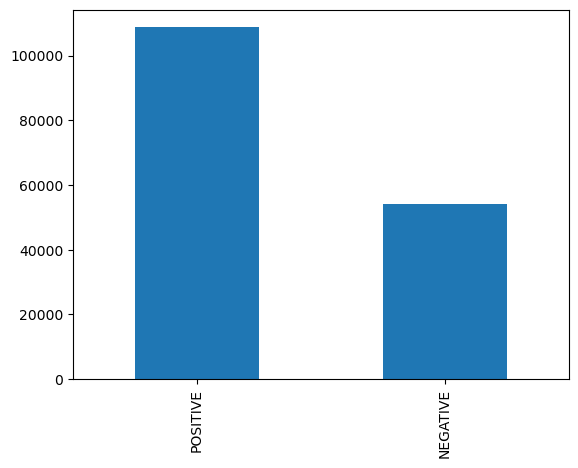

In [16]:
train.sentiment.value_counts().plot(kind='bar')

In [17]:
train.sentiment.value_counts()

POSITIVE    108761
NEGATIVE     53997
Name: sentiment, dtype: int64

**Observation:** The number of **positive** reviews is **twice** that of the **negative** reviews

**Inference:** Data authenticity is higher as movie reviews tend to be more positive than negative; unlike in other sentiment analyses eg. Tweets, chatrooms etc

In [18]:
train.head()

,movieid,reviewerName,isFrequentReviewer,reviewText,sentiment
0,marvelous_pirate,Benjamin Henry,False,Henry Selick’s first movie since 2009’s Corali...,POSITIVE
1,tony_montana_frodo_baggins_v_rocky_balboa,Felicia Lopez,False,With a cast that reads like the Vogue Oscar pa...,NEGATIVE
2,darth_vader_katniss_everdeen_sorcerer_donnie_d...,Mr. Charles Burgess,True,Creed II does not give us anything but another...,POSITIVE
3,lara_croft_glimmer,Ryan Barrett,False,"I know what you're thinking, but this is no Li...",POSITIVE
4,jason_bourne_surreal_the_terminator_indiana_jones,Alexander Glover,False,Director Fernando Meirelles tells the story wi...,POSITIVE


In [19]:
train.reviewText[0], train.sentiment[0]

('Henry Selick’s first movie since 2009’s Coraline. His fifth stop-motion masterpiece.',
 'POSITIVE')

In [20]:
train.reviewText[1], train.sentiment[1]

("With a cast that reads like the Vogue Oscar party guest list, Valentine's Day should have been can't-miss cinema instead of standard Hollywood schmaltz.",
 'NEGATIVE')

In [21]:
train.reviewText[2], train.sentiment[2]

("Creed II does not give us anything but another, slightly superior Rocky sequel. It wins on points. Just don't expect a knockout.",
 'POSITIVE')

**Observation:** Stop words cannot be ignored in sentiment analysis.
eg. should,can't etc, as seen in the above example

These words are vital in determining the sentiment of the text

**Inference:** Need a **custom stop words list** instead of the internally provided one

In [22]:
train.reviewerName.value_counts()

Sherri Morrison      962
Veronica Serrano     952
Mrs. Vickie Young    827
Kristy Ferguson      822
Heather Pena         797
                    ... 
Ashley Munoz           1
Ryan Dean              1
Joanna Li              1
Jason Carroll          1
Chad Mueller           1
Name: reviewerName, Length: 4482, dtype: int64

In [23]:
train.loc[train.sentiment=='POSITIVE'].reviewerName.value_counts()

Veronica Serrano    629
Heather Pena        592
Danielle Jimenez    591
Sherri Morrison     584
Laura Lawrence      546
                   ... 
Kendra Cole           1
Jimmy Moore DDS       1
Tara Hanson           1
Collin Flores MD      1
Cathy Hines           1
Name: reviewerName, Length: 4295, dtype: int64

In [24]:
train.loc[train.sentiment=='NEGATIVE'].reviewerName.value_counts()

Kristy Ferguson      489
James Newman         381
Sherri Morrison      378
Mrs. Vickie Young    357
Sharon Foster        347
                    ... 
Dylan Williams         1
Linda Padilla          1
Tara Hanson            1
Linda Murphy           1
Luke Forbes            1
Name: reviewerName, Length: 3476, dtype: int64

# DATA PREPROCESSING

In [25]:
#Dropping the empty values in the dataset
train=train.dropna()

In [26]:
train.isna().sum()

movieid               0
reviewerName          0
isFrequentReviewer    0
reviewText            0
sentiment             0
dtype: int64

In [27]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 156311 entries, 0 to 162757
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   movieid             156311 non-null  object
 1   reviewerName        156311 non-null  object
 2   isFrequentReviewer  156311 non-null  bool  
 3   reviewText          156311 non-null  object
 4   sentiment           156311 non-null  object
dtypes: bool(1), object(4)
memory usage: 6.1+ MB


In [28]:
#Splitting the features and label
X=train[["reviewText","reviewerName"]]
y=train['sentiment']

In [29]:
# Splitting the dataset for internal validation
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25)

In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 117233 entries, 160444 to 10968
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   reviewText    117233 non-null  object
 1   reviewerName  117233 non-null  object
dtypes: object(2)
memory usage: 2.7+ MB


In [31]:
#Custom stop words list
sw2=['the','a','an','he','she','I','me','myself','him','his','her','herself','it','itself','it','this','that','in','we','our','ourselves','ours','that','these','am','is']

# **Pipeline for Model Training**

In [32]:
cat_features=['reviewerName']#categorical feature-Name
text_features='reviewText'#text feature

In [33]:
cat_steps=[('le',OneHotEncoder(handle_unknown='ignore'))]#One Hot Encoding the Names
cat_transformer=Pipeline(steps=cat_steps)

In [34]:
sw2=['the','a','an','he','she','I','me','myself','him','his','her','herself','it','itself','it','this','that','in','we','our','ourselves','ours','that','these','am','is']

In [35]:
#Using CountVectorizer and TfidfTransformer
#ngram_range=(1,2) vectorizes by taking 2 words as a single vector also 
text_steps=[('countvec',CountVectorizer(stop_words=sw2,ngram_range=(1,2))),('tfidf',TfidfTransformer())]
text_transformer=Pipeline(steps=text_steps)

In [36]:
trans_steps=[('cat',cat_transformer,cat_features),('text',text_transformer,text_features)]
pre_pipe=ColumnTransformer(transformers=trans_steps)# combining the individual pipes

# Logistic Regression

In [37]:
#Creating a LogisticRegression Pipeline
lgpipe=Pipeline(steps=[('pre',pre_pipe),('classifier',LogisticRegression(C=2,max_iter=1000,random_state=1))])

In [38]:
lgpipe.fit(X_train,y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('le',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['reviewerName']),
                                                 ('text',
                                                  Pipeline(steps=[('countvec',
                                                                   CountVectorizer(ngram_range=(1,
                                                                                                2),
                                                                                   stop_words=['the',
                                                                                               'a',
                                                                                               'an',
                                                                                               'he',
                                                                                               'she',
                                                                                               'I',
                                                                                               'me',
                                                                                               'myself',
                                                                                               'him',
                                                                                               'his',
                                                                                               'her',
                                                                                               'herself',
                                                                                               'it',
                                                                                               'itself',
                                                                                               'it',
                                                                                               'this',
                                                                                               'that',
                                                                                               'in',
                                                                                               'we',
                                                                                               'our',
                                                                                               'ourselves',
                                                                                               'ours',
                                                                                               'that',
                                                                                               'these',
                                                                                               'am',
                                                                                               'is'])),
                                                                  ('tfidf',
                                                                   TfidfTransformer())]),
                                                  'reviewText')])),
                ('classifier',
                 LogisticRegression(C=2, max_iter=1000, random_state=1))])

In [39]:
lgpipe.score(X_train,y_train)

0.9404348604914998

In [40]:
lgpipe.score(X_test,y_test)

0.8232765238753262

In [41]:
lgtestpred=lgpipe.predict(X_test)

In [42]:
conf_mat=confusion_matrix(y_test,lgtestpred)

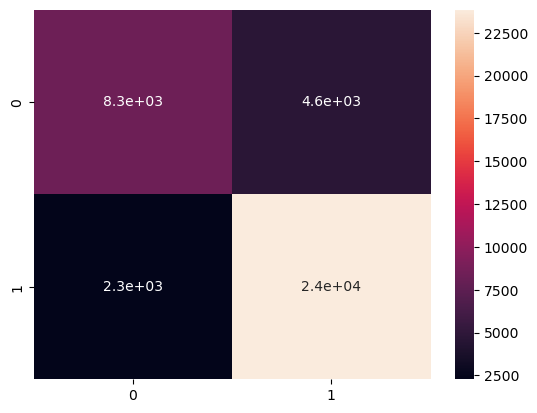

In [43]:
cm=sns.heatmap(conf_mat,annot=True)


In [44]:
#fitting the Logistic Regression Pipeline on the data
lgpipe.fit(X,y)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('le',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['reviewerName']),
                                                 ('text',
                                                  Pipeline(steps=[('countvec',
                                                                   CountVectorizer(ngram_range=(1,
                                                                                                2),
                                                                                   stop_words=['the',
                                                                                               'a',
                                                                                               'an',
                                                                                               'he',
                                                                                               'she',
                                                                                               'I',
                                                                                               'me',
                                                                                               'myself',
                                                                                               'him',
                                                                                               'his',
                                                                                               'her',
                                                                                               'herself',
                                                                                               'it',
                                                                                               'itself',
                                                                                               'it',
                                                                                               'this',
                                                                                               'that',
                                                                                               'in',
                                                                                               'we',
                                                                                               'our',
                                                                                               'ourselves',
                                                                                               'ours',
                                                                                               'that',
                                                                                               'these',
                                                                                               'am',
                                                                                               'is'])),
                                                                  ('tfidf',
                                                                   TfidfTransformer())]),
                                                  'reviewText')])),
                ('classifier',
                 LogisticRegression(C=2, max_iter=1000, random_state=1))])

**Hyperparameter tuning**

In [45]:
#Tuning the C value to optimise regularisation
paramslg={
    'classifier__C':[0.1,1,2,3]
}

In [46]:
#rscv=RandomizedSearchCV(lgpipe,paramslg)

In [47]:
#rscv.fit(X_train,y_train)

In [48]:
#rscv.best_params_

{'classifier__C': 2}

# SUPPORT VECTOR MACHINE

In [49]:
#LinearSVC is used as the dataset is voluminous
#svpipe=Pipeline(steps=[('pre',pre_pipe),('classifier',LinearSVC(C=0.1,dual=False,random_state=1))])

In [50]:
#svpipe.fit(X_train,y_train)

In [51]:
#svpipe.score(X_train,y_train)

In [52]:
#svpipe.score(X_test,y_test)

**Hyperparameter tuning**

In [53]:
paramsvm={
    'classifier__penalty':['l1','l2'],'classifier__loss':['hinge','squared_hinge'],'classifier__C':[0.01,0.1,1,10],'classifier__fit_intercept':[True,False]}

In [54]:
#rscvsvm=RandomizedSearchCV(svpipe,paramsvm)

In [55]:
#rscsvm.fit(X_train,y_train)

In [56]:
#rscvsvm.best_params_

{'classifier__penalty': 'l2',
 'classifier__loss': 'squared_hinge',
 'classifier__fit_intercept': False,
 'classifier__C': 0.1}

In [57]:
#svpipe.fit(X,y)

**LinearSVM score=0.81561**

# NAIVE BAYES CLASSIFIER

In [58]:
#bernbpipe=Pipeline(steps=[('pre',pre_pipe),('classifier',BernoulliNB(alpha=0.2))])

In [59]:
#bernbpipe.fit(X_train,y_train)

In [60]:
#bernbpipe.score(X_train,y_train)

In [61]:
#bernbpipe.score(X_test,y_test)

In [62]:
paramsnb={
    'classifier__alpha':[0.1,0.2,0.3]
}
#the alpha parameter is tuned to regularise the classifier and prevent zero probability occurences

In [63]:
#rscvnb=RandomizedSearchCV(bernbpipe,paramsnb)

In [64]:
#rscvnb.fit(X_train,y_train)

In [65]:
#rscvnb.best_params_

{'classifier__alpha': 0.2}

**Bernoulli NB Score:0.81182**

In [66]:
#mnbpipe=Pipeline(steps=[('pre',pre_pipe),('classifier',MultinomialNB(alpha=0.1))])

In [67]:
#mnbpipe.fit(X_train,y_train)

In [68]:
#mnbpipe.score(X_train,y_train)

In [69]:
#mnbpipe.score(X_test,y_test)

In [70]:
paramsmnb={
    'classifier__alpha':[0.1,0.2,0.3]
}

In [71]:
#rsmnb=RandomizedSearchCV(mnbpipe,paramsmnb)

In [72]:
#rsmnb.fit(X_train,y_train)

In [73]:
#rsmnb.best_params_

{'classifier__alpha': 0.1}

**Multinomial NB score: 0.7996**

# DECISION TREE CLASSIFIER

In [74]:
dtc=tree.DecisionTreeClassifier(max_depth=40,min_samples_split=50,random_state=1)

In [75]:
#dtcpipe=Pipeline(steps=[('pre',pre_pipe),('classifier',dtc)])


In [76]:
#dtcpipe.fit(X_train,y_train)

In [77]:
#dtcpipe.score(X_train,y_train)

In [78]:
#dtcpipe.score(X_test,y_test)

In [79]:
#max_depth-to limit the no of 
paramsdtc={
    'classifier__max_depth':[20,40,60],'classifier__min_samples_split':[50,100,150]
}

{'classifier__max_depth':20, 'classifier__min_samples_split':50
}

In [80]:
#dtcpipe.fit(X,y)

**Decision Tree Classifier score: 0.69733**

# Performance of models

3 **discriminative** models are used

    1)Logistic Regression- score= 0.82133
    2)Support Vector Machine- score= 0.81561
    3)Decision Tree Classifier- score= 0.69733
    
  The LogisticRegression Model and Support Vector Machine give a similar score
  but the Decision Tree Classifier gives a much lower score possibly due to class imbalance as the optimal hyperparameters are fit.
  
  In SVM lower C is used to widen the margin between support vectors thus making the model have a better performance on test data
  
  In Logistic Regression C value of 2 makes sure the model doesnt underfit
  
    
1 **generative** model is used

    1.a) Bernoulli Naive Bayes- score= 0.8112
    1.b) Multinomial Naive Bayes- score= 0.7996
    
   Bernoulli does prediction based on the presence/absence of a feature while,
   Multinomial counts the no of times a feature/word occurs.
   Bernoulli model takes a edge possibly due to modelling on presence of negative words like isn't, but, not etc.
   
   Multinomial over relies on the multiplicity of certain words and possibly overfits
   

**Prediction on test data**

In [81]:
test.isna().sum()

movieid            0
reviewerName       0
isTopCritic        0
reviewText      2510
dtype: int64

In [82]:
#Filling the null reviewText
test1=test.fillna('')

In [83]:
pred=lgpipe.predict(test1)

In [84]:
#predsv=svpipe.predict(test1)

In [85]:
type(test1)

pandas.core.frame.DataFrame

In [86]:
L=[]
for i in range(len(pred)):
    L.append(i)

In [87]:
finalpred=pd.DataFrame({'id':L,'sentiment':pred})
finalpred.to_csv('submission.csv',index=False)

In [88]:
d=pd.read_csv('submission.csv')

In [89]:
d

,id,sentiment
0,0,POSITIVE
1,1,POSITIVE
2,2,POSITIVE
3,3,POSITIVE
4,4,POSITIVE
...,...,...
55310,55310,POSITIVE
55311,55311,NEGATIVE
55312,55312,NEGATIVE
55313,55313,POSITIVE
